# EDA
In this notebook we will:
- download the raw data zip file
- extract the OCT folder from this zip, as we do not need the other data
- combine the test and train set since we need to create our own more rigorous splits later

- explore the data
- group by patient

NOTE: image file names are in form  **(disease)-(randomized patient ID)-(image number by this patient)**

Hence we need to be mindful of time series, ie group by patient id so they dont have some in training and some in testing

In [32]:
# imports
import requests
import hashlib
from pathlib import Path
from zipfile import ZipFile
from io import BytesIO
import shutil

In [40]:
# create directory structure
parent_dir = Path.cwd().parent
# raw dir
raw_dir = parent_dir / "data" / "raw"
raw_dir.mkdir(parents=True, exist_ok=True)
# processed dir
processed_dir = parent_dir / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

# constants
DATA_URL = "https://data.mendeley.com/public-api/zip/rscbjbr9sj/download/3" # "ZhangLabData.zip"
SHA256_CHECKSUM = "8b779fb84d899a2130605165fd2c79e8f4d0e35d6e231ed8b3f29b5981110972"
CHUNK_SIZE = 10 * 1024 * 1024  # 10MB
OUTPUT_ZIP_PATH = parent_dir / "data/dataset.zip"
CLASSES = ["CNV", "DME", "DRUSEN", "NORMAL"]

print(OUTPUT_ZIP_PATH)

/home/lance/Projects/SML/COMP90051_A2/data/dataset.zip


In [12]:
# download data, stream in the zip file
resp = requests.get(DATA_URL, stream = True)

with open(OUTPUT_ZIP_PATH, "wb") as f:
    for chunk in resp.iter_content(chunk_size = CHUNK_SIZE): 
        f.write(chunk)

print("Download zip complete")

Download zip complete


In [34]:
# check sum to ensure correct download
sha256 = hashlib.sha256()

# open to read
with open(OUTPUT_ZIP_PATH, "rb") as f:
    for chunk in iter(lambda: f.read(CHUNK_SIZE*2), b""): # read until empty bytes b""
        sha256.update(chunk)

downloaded_sha256 = sha256.hexdigest()

if downloaded_sha256 == SHA256_CHECKSUM:
    print("Checksum matches :)")
else:
    print("Checksum doesnt match :(")

Checksum matches :)


In [45]:
# unzip file, then inside nested zip get OCT directory only
with ZipFile(OUTPUT_ZIP_PATH) as outer:
    # find nested zip
    nested_zip_name = next(
        name for name in outer.namelist()
        if name.endswith("ZhangLabData.zip")
    )
    # stream nested zip directly
    with outer.open(nested_zip_name) as nested_zip_file:
        with ZipFile(nested_zip_file) as inner:
            # iterate ONCE
            for member in inner.infolist():
                file_path = member.filename
                # only OCT files
                if "CellData/OCT/" not in file_path:
                    continue
                # keep only path after OCT/
                oct_index = file_path.index("OCT/")
                relative_path = file_path[oct_index:]

                target_path = raw_dir / relative_path

                # check if dir
                if member.is_dir():
                    target_path.mkdir(parents=True, exist_ok=True)
                    continue

                target_path.parent.mkdir(parents=True, exist_ok=True)
                # stream copy 
                with inner.open(member) as src, open(target_path, "wb") as dst:
                    shutil.copyfileobj(src, dst)

print("Extracted data from zip")

Extracted data from zip


In [46]:
# join the datasets from train test split
import shutil
oct_path =  raw_dir / "OCT"

for split in ["train", "test"]:
    split_path = oct_path / split

    # go through each subfoler
    for class_folder in split_path.iterdir():
        # ignore non CNV DME DRUSEN NORMAL folders
        if not class_folder.is_dir():
            continue

        # go through every image in the class folder
        for image_path in class_folder.iterdir():
            if not image_path.is_file():
                continue
            shutil.copy(image_path, raw_dir / image_path.name)
print("Joined test and train sets")

Joined test and train sets


In [ ]:
# delete the OCT directory

# count in OCT
oct_count = sum(1 for path in (raw_dir / "OCT").rglob("*") if path.is_file())

# merged count in raw/... that arent OCT
merged_count = sum(1 for path in (raw_dir).glob("*") if path.is_file())

print(f"OCT files {oct_count}, Merged files {merged_count}")

if oct_count == merged_count:
    print("files all put from test/train into joined folders, delete OCT folder")
    shutil.rmtree(oct_path)
else:
    print("Did not copy correctly")

OCT files 109309, Merged files 109309
files all put from test/train into joined folders, delete OCT folder


# Data exploration

Now we have read in the data successfully, we have data/raw/.... with a folder for each class

In [57]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [51]:
# create df by filenames to look at data distribution
rows = []
for file in raw_dir.glob("*.jpeg"):
    stem = file.stem  # file name w no extension
    try:
        disease, patient_id, image_num = stem.split("-")

        rows.append({
            "disease": disease,
            "patient_id": patient_id,
            "image_num": int(image_num),
            "filename": file.name,
            "path": str(file)
        })
    except:
        print(f"Skipping: {file.name}")

df = pd.DataFrame(rows)
print(df.head())

  disease patient_id  image_num                filename  \
0     CNV    3453634         13     CNV-3453634-13.jpeg   
1     CNV    7513011         89     CNV-7513011-89.jpeg   
2     DME    5313093         77     DME-5313093-77.jpeg   
3     CNV    9374492        279    CNV-9374492-279.jpeg   
4  NORMAL    5768195         14  NORMAL-5768195-14.jpeg   

                                                path  
0  /home/lance/Projects/SML/COMP90051_A2/data/raw...  
1  /home/lance/Projects/SML/COMP90051_A2/data/raw...  
2  /home/lance/Projects/SML/COMP90051_A2/data/raw...  
3  /home/lance/Projects/SML/COMP90051_A2/data/raw...  
4  /home/lance/Projects/SML/COMP90051_A2/data/raw...  


<Axes: xlabel='disease'>

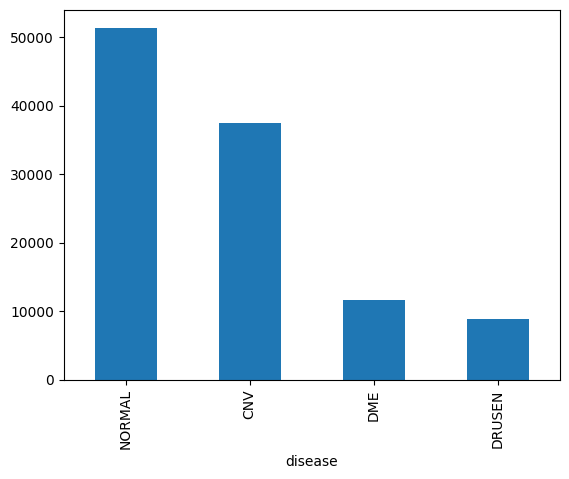

In [54]:
# class balance
df["disease"].value_counts().plot(kind="bar")

     disease patient_id  images_num
29       CNV    1188386         813
622      CNV    6652117         613
623      CNV    6666538         585
757      CNV    7907754         469
908      CNV    9374492         459
...      ...        ...         ...
1328     DME    4957841           1
1271     DME    4644266           1
1279     DME    4669768           1
1280     DME    4680138           1
1303     DME     483195           1

[6332 rows x 3 columns]


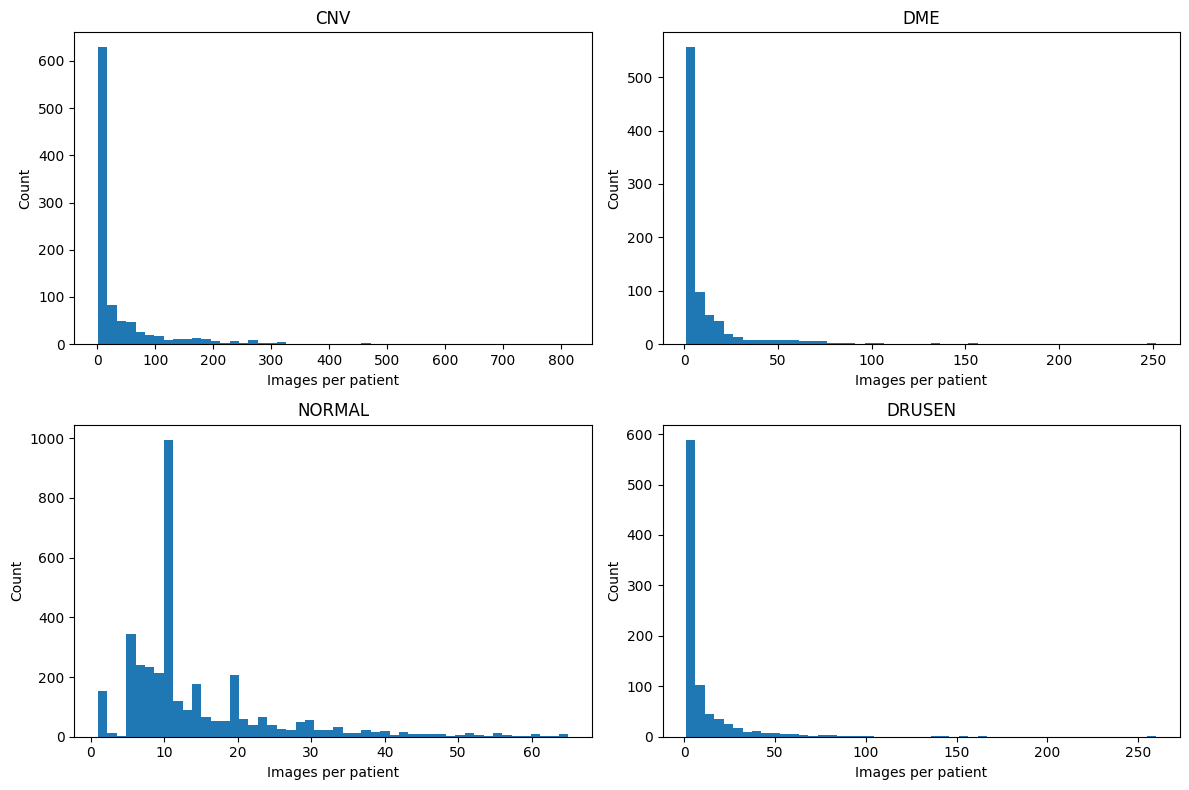

In [ ]:
patient_counts = (
    df.groupby(["disease", "patient_id"])
      .size()
      .reset_index(name="images_num")
)
print(patient_counts.sort_values(by = "images_num", ascending=False))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# plot the distribution of number of images per patient for each disease
diseases = df["disease"].unique()
for i in range(len(diseases)):
    disease = diseases[i]
    subset = patient_counts[patient_counts["disease"] == disease]

    ax = axes.flat[i]
    ax.hist(subset["images_num"], bins=50)
    ax.set_title(disease)
    ax.set_xlabel("Images per patient")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

Number of patients with images in multiple diseases: 787


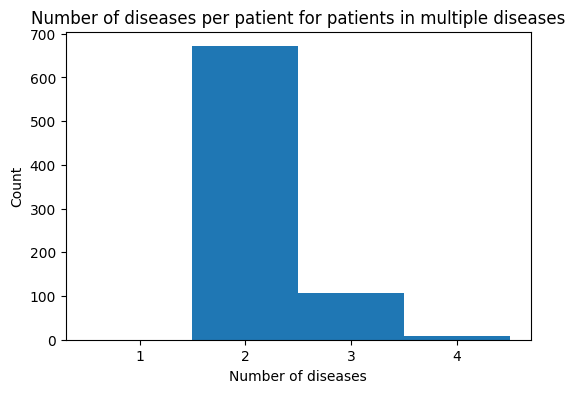

In [71]:
# check if the same patient id has images in multiple diseases
patient_disease_counts = df.groupby("patient_id")["disease"].nunique()
patients_in_multiple_diseases = patient_disease_counts[patient_disease_counts > 1]
print(f"Number of patients with images in multiple diseases: {len(patients_in_multiple_diseases)}")

# plot how many diseases each patient id has images in for those with multiple diseases
fig = plt.figure(figsize=(6, 4))
plt.hist(patient_disease_counts.loc[patients_in_multiple_diseases.index], bins=np.arange(1, patient_disease_counts.max() + 2) - 0.5)
plt.title("Number of diseases per patient for patients in multiple diseases")
plt.xlabel("Number of diseases")
plt.ylabel("Count")
plt.xticks(np.arange(1, patient_disease_counts.max() + 1))
plt.show()



From this we **assume that the patient ID is not globally unique**, and the randomised ID is only unqiue within
its given subfolder of disease class. 

In [75]:
# Lastly lets check how many patients there are per disease
df.groupby("disease")["patient_id"].nunique()

disease
CNV        969
DME        876
DRUSEN     882
NORMAL    3605
Name: patient_id, dtype: int64

In [76]:
# total number of patients across all diseases
df.groupby("disease")["patient_id"].nunique().sum()

np.int64(6332)